# Figure 3: Dynamics of decision parameters across action costs.

## setup and imports

In [1]:
import fnmatch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import glob

from sessionlists import (dist60, dist90, dist120, TM20, TM10, TM2, TMrev2, TMrev10, TMrev20)
from utils import *
from plotting import *
from model_functions import *
from initialize_notebook import initialize_notebook

plt.style.use('./Figures/paper.mplstyle')

In [2]:
root, rat_lists, rat_markers, (example_rat, example_session), GENERAL_PLOT_PARAMS = initialize_notebook()
intact_rats, *_ = rat_lists

sequence = {}
for index, animal in enumerate(intact_rats):
    for session in sorted(matchsession(animal, dist60+dist90+dist120 + TM20+TM10+TM2+TMrev2+TMrev10+TMrev20)):
        sequence[animal, session] = get_from_pickle(root, animal, session, name="sequence.p")


Found 84 rats in the DATA folder
Listed 57 rats in total, of which 19 are intact (8♀, 11♂), 19 DS lesions, 15 VS lesions and 4 shams.
Example rat is RatM00, example session: RatM00_2021_07_22_16_13_03


# Figure 3A Schematics of three action cost conditions with increasing platform distances.
# Figure 3D Same with treadmill velocity.

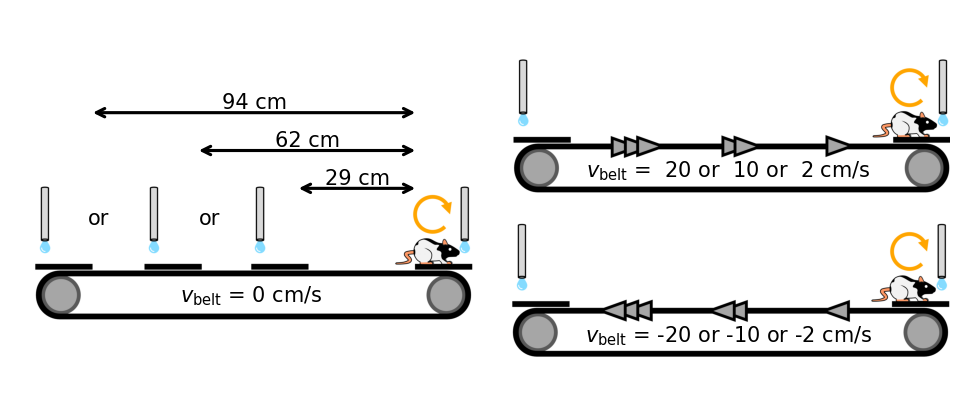

In [3]:
def Figure3A(ax=None, path=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    if path is None:
        path = "./Figures/3Aidle.png"

    img = plt.imread(path)
    img = img[300:2600, 150:3075]
    img = np.concatenate((np.ones((300, img.shape[1], 3), dtype=np.uint8), img), axis=0)
    
    ax.imshow(img)
    ax.axis("off")
    ax.text(s=r'$v_{\mathrm{belt}}$ = 0 cm/s', x=img.shape[1]/2, y=1760, ha="center", va="center", fontsize=5)
    ax.text(s='or', x=450, y=1250, ha="center", va="center", fontsize=5)
    ax.text(s='or', x=1185, y=1250, ha="center", va="center", fontsize=5)

    ax.annotate(text='', xy=(1720, 1050), xytext=(2600, 1050), arrowprops=dict(arrowstyle='<->', lw=0.75), fontsize=5, zorder=5)
    ax.annotate(text='', xy=(1060, 800), xytext=(2600, 800), arrowprops=dict(arrowstyle='<->', lw=0.75), fontsize=5, zorder=5)
    ax.annotate(text='', xy=(360, 550), xytext=(2600, 550), arrowprops=dict(arrowstyle='<->', lw=0.75), fontsize=5, zorder=5)
    
    ax.annotate(text='29 cm', xy=(0, 0), xytext=((1720+2600)/2, 1050), ha='center', va='bottom', xycoords='data', fontsize=5, zorder=5)
    ax.annotate(text='62 cm', xy=(0, 0), xytext=((1060+2600)/2, 800), ha='center', va='bottom', xycoords='data', fontsize=5, zorder=5)
    ax.annotate(text='94 cm', xy=(0, 0), xytext=((360+2600)/2, 550), ha='center', va='bottom', xycoords='data', fontsize=5, zorder=5)

def Figure3D(ax=None, path=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    if path is None:
        path = "./Figures/3Didle.png"

    img = plt.imread(path)
    img = img[:, 150:3075]
    ax.imshow(img)
    ax.axis("off")
    ax.text(s=r'$v_{\mathrm{belt}}$ =  20 or  10 or  2 cm/s', x=img.shape[1]/2, y=930, ha="center", va="center", fontsize=5)
    ax.text(s=r'$v_{\mathrm{belt}}$ = -20 or -10 or -2 cm/s', x=img.shape[1]/2, y=2020, ha="center", va="center", fontsize=5)

fig, axs = plt.subplots(1, 2, figsize=(cm2inch(8), cm2inch(4)))
Figure3A(ax=axs[0])
Figure3D(ax=axs[1])

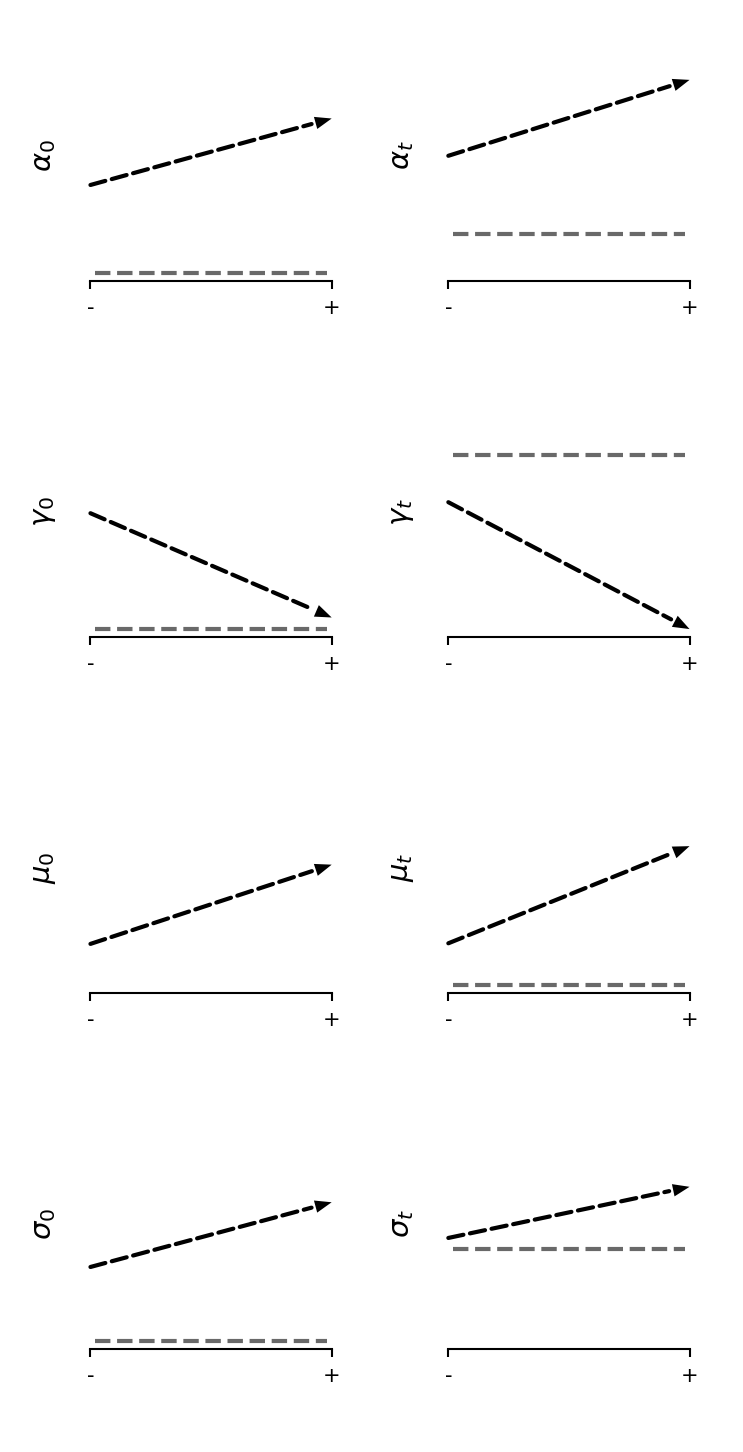

In [4]:
alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
ex_alpha_0, ex_alpha_t, ex_alpha_u, ex_gamma_0, ex_gamma_t, ex_gamma_u = pickle.load(open("picklejar/example_session_fit_inter_run_duration.p", "rb"))
ex_mu_0, ex_mu_t, ex_mu_u, ex_sigma_0, ex_sigma_t, ex_sigma_u = pickle.load(open("picklejar/example_session_fit_run_duration.p", "rb"))

PLOT_PARAMS = {
    'alpha_0':  dict(fit=alpha_0, ex_fit=ex_alpha_0, yticks=GENERAL_PLOT_PARAMS['alpha_0']['yticks_I'], ylabel=GENERAL_PLOT_PARAMS['alpha_0']['ylabel'],start='med', end=2),
    'alpha_t':  dict(fit=alpha_t, ex_fit=ex_alpha_t, yticks=GENERAL_PLOT_PARAMS['alpha_t']['yticks_I'], ylabel=GENERAL_PLOT_PARAMS['alpha_t']['ylabel'], start='med', end=0.4),
    'gamma_0':  dict(fit=gamma_0, ex_fit=ex_gamma_0, yticks=GENERAL_PLOT_PARAMS['gamma_0']['yticks_I'], ylabel=GENERAL_PLOT_PARAMS['gamma_0']['ylabel'], start=1, end=.1),
    'gamma_t':  dict(fit=gamma_t, ex_fit=ex_gamma_t, yticks=GENERAL_PLOT_PARAMS['gamma_t']['yticks_I'], ylabel=GENERAL_PLOT_PARAMS['gamma_t']['ylabel'], start='med', end=-.15),
    'mu_0':     dict(fit=mu_0, ex_fit=ex_mu_0, yticks=GENERAL_PLOT_PARAMS['mu_0']['yticks_I'], ylabel=GENERAL_PLOT_PARAMS['mu_0']['ylabel'], start='med', end='med'),
    'mu_t':     dict(fit=mu_t, ex_fit=ex_mu_t, yticks=GENERAL_PLOT_PARAMS['mu_t']['yticks_I'], ylabel=GENERAL_PLOT_PARAMS['mu_t']['ylabel'], start='med', end=.12),
    'sigma_0':  dict(fit=sigma_0, ex_fit=ex_sigma_0, yticks=GENERAL_PLOT_PARAMS['sigma_0']['yticks_I'], ylabel=GENERAL_PLOT_PARAMS['sigma_0']['ylabel'], start='med', end=.15),
    'sigma_t':  dict(fit=sigma_t, ex_fit=ex_sigma_t, yticks=GENERAL_PLOT_PARAMS['sigma_t']['yticks_I'], ylabel=GENERAL_PLOT_PARAMS['sigma_t']['ylabel'], start='med', end=0.04),
}

def plot_prediction(param_name, ax=None, show_xlabel=False, show_ylabel=True, intact_rats=intact_rats):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    params = PLOT_PARAMS[param_name]

    if isinstance(params['start'], str):
        if params['start'] == 'med':
            start = np.median([params['fit'][animal]["60"] for animal in intact_rats])
    elif isinstance(params['start'], (float, int)):
        start = params['start']
    else:
        raise ValueError("Start value must be a string ('med') or a float/int.")

    if isinstance(params['end'], str):
        if params['end'] == 'med':
            end = np.median([params['fit'][animal]["rev20"] for animal in intact_rats])
        if params['end'] == 'start':
            end = start
    elif isinstance(params['end'], (float, int)):
        end = params['end']
    else:
        raise ValueError("End value must be a string ('med', 'start') or a float/int.")

    mock_data = [start, start + (end - start) / 2, end]
    # ax.plot([0, 1, 2], mock_data, color='k', lw=.75, markersize=2, linestyle='-')
    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1, alpha=1, zorder=0, xmin=.1, xmax=.9)


    arrowStart = (0, mock_data[0])
    arrowStop = (2, mock_data[2])
    arrowColor = 'k'
    ax.annotate("", arrowStop, xytext=arrowStart, arrowprops=dict(arrowstyle="-", shrinkA=0, shrinkB=5, edgecolor=arrowColor, facecolor="none", linestyle="dashed"))
    ax.annotate("", arrowStop, xytext=arrowStart, arrowprops=dict(linewidth=0, arrowstyle="-|>,head_width=0.15,head_length=0.4", shrinkA=0, shrinkB=0, edgecolor="none", facecolor=arrowColor, linestyle="solid"))


    ax.set_xlim(0, 2)
    ax.set_xticks([0, 2])
    ax.set_xticklabels(["-", "+"])
    if show_xlabel:
        ax.set_xlabel("Cost")
    else:
        ax.set_xlabel(" ")


    ax.set_ylim(params['yticks'][0], params['yticks'][-1])
    ax.set_yticks(params['yticks'])
    ax.yaxis.set_major_formatter('{x:<5.2f}')
    ax.spines['left'].set_visible(False)
    ax.tick_params(left=False, labelleft=False)

    if show_ylabel:
        ax.set_ylabel(params['ylabel'])

    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1, top_y=0.05)


fig, axs = plt.subplots(4, 2, figsize=(cm2inch(6), cm2inch(12)))

param_names = ['alpha_0', 'alpha_t', 'gamma_0', 'gamma_t',
                'mu_0', 'mu_t', 'sigma_0', 'sigma_t']

for ax, param_name in zip(axs.ravel(), param_names):
    plot_prediction(param_name, ax=ax)


In [5]:
def add_slope_pvalue(var, ax, dist_or_tm, num_iterations=10000):
    rows = []
    _ = {"60": 0, "90": 1, "120": 2, "20": 0, "10": 1, "2": 2, "rev10": 3, "rev20": 4}

    for animal in intact_rats:
        if dist_or_tm == 'dist':
            conds = ["60", "90", "120"]
        elif dist_or_tm == 'tm':
            conds = ["20", "10", "2", "rev10", "rev20"]
        else:
            raise ValueError("experiment must be 'dist' or 'tm'")
        for cond in conds:
            x = float(_[cond])
            y = var['fit'][animal][cond]
            rows.append({"animal": animal, "parameter": y, "cond": x})

    df = pd.DataFrame(rows)
    x = df.cond
    y = df.parameter

    # fit with np.polyfit
    f = lambda x, *p: np.polyval(p, x)
    p, cov = curve_fit(f, x, y, [1, 1])

    # shuffle to get p-value
    observed_slope = p[0]
    observed_intercept = p[1]
    slope_sign = np.sign(observed_slope)
    num_iterations = int(num_iterations)
    shuffled_slopes = []
    shuffled_intercepts = []
    np.random.seed(0)
    for _ in range(num_iterations):
        shuffled_y = np.random.permutation(y)
        shuffled_res, _ = curve_fit(f, x, shuffled_y, [1, 1])
        shuffled_slopes.append(shuffled_res[0])
        shuffled_intercepts.append(shuffled_res[1])

    # calculate the p-value
    p_value_slope = (np.abs(shuffled_slopes) >= np.abs(observed_slope)).mean()
    # if observed_intercept >= 0:
    #     p_value_intercept = (np.asarray(shuffled_intercepts) <= 0).mean()
    # else:
    #     p_value_intercept = (np.asarray(shuffled_intercepts) >= 0).mean()
    c = 'k' if p_value_slope < 0.05 else 'gray'
    x = 0.5
    if p_value_slope < .001:
        text = f"< 0.001"
    elif p_value_slope <= .06:
        text = f"= {p_value_slope:.3f}"
    else:
        text = f"= {p_value_slope:.2f}"
    if var == PLOT_PARAMS['alpha_0']:
        ax.text(s=rf'$p_{{slope}} {text}$', x=x, y=ax.get_ylim()[1]*0.9, fontsize=4, c=c)
    elif var == PLOT_PARAMS['mu_0'] and dist_or_tm == 'dist':
        ax.text(s=f'$p {text}$', x=0, y=ax.get_ylim()[1]*0.9, fontsize=4, c=c)
    else : 
        ax.text(s=f'$p {text}$', x=x, y=ax.get_ylim()[1]*0.9, fontsize=4, c=c)

# 3B Effect of distance on α0, αt and αu
# 3C Effect of distance on γ0, γt and γu

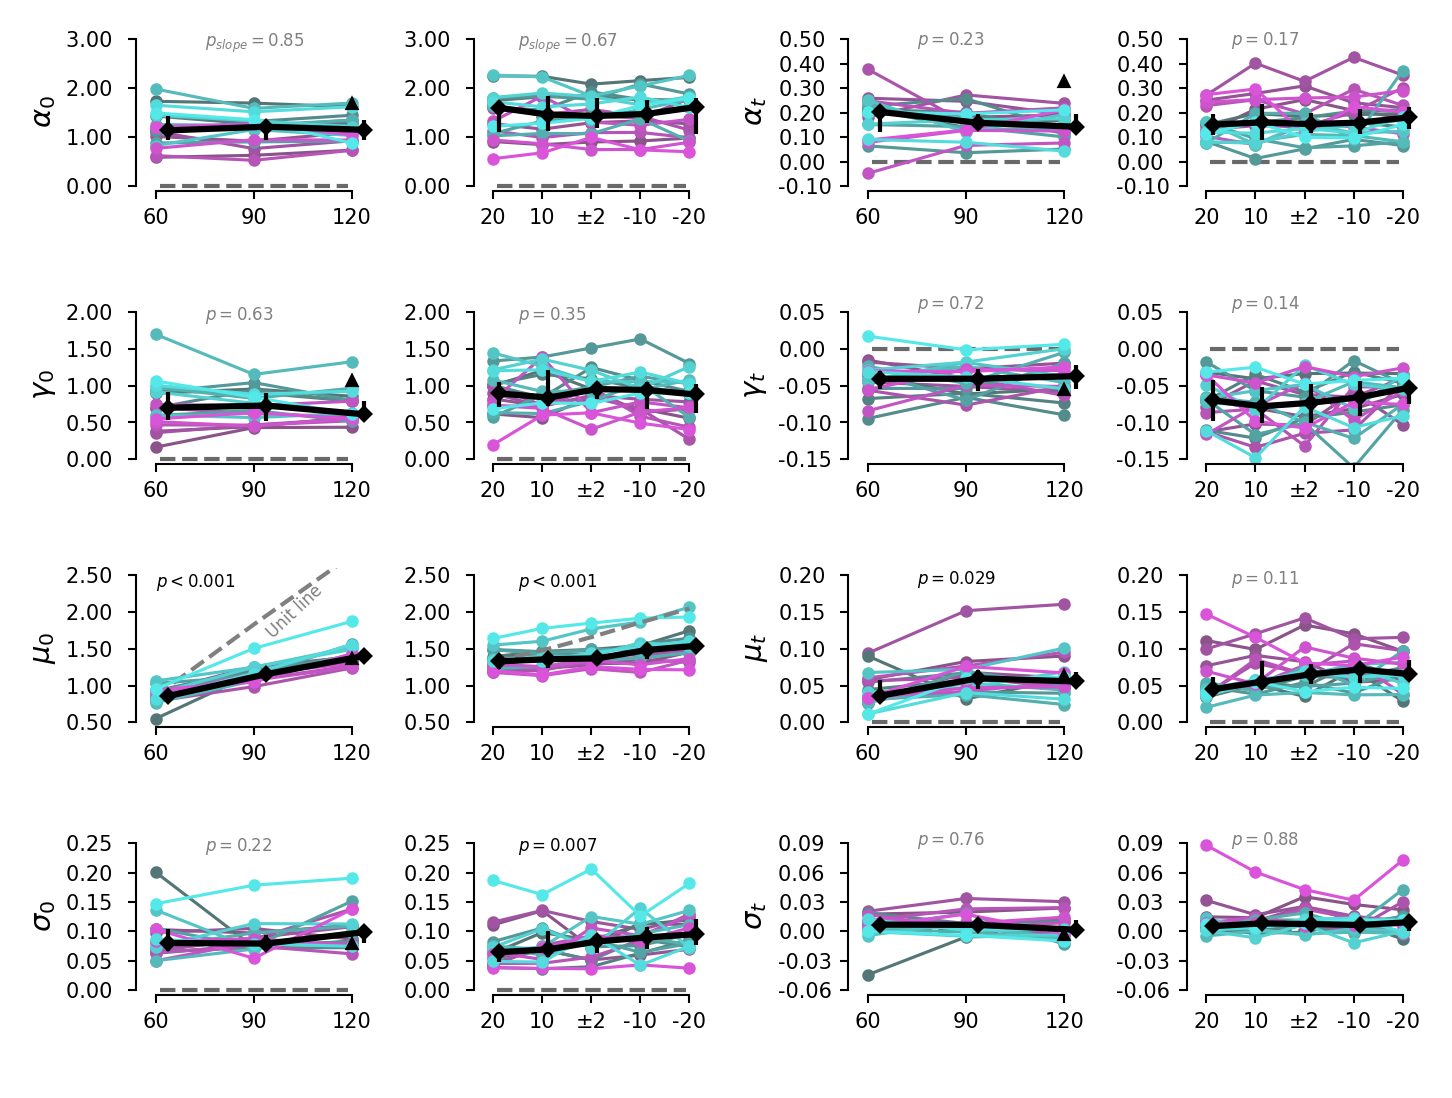

In [6]:
fig, axs = plt.subplots(4, 4, figsize=(cm2inch(12), cm2inch(9)))
param_names = [name for name in list(PLOT_PARAMS.keys()) for _ in (0, 1)]

for i, ax in enumerate(axs.ravel()):
    if i % 2 == 0:
        dist_or_tm = 'dist'
    else:
        dist_or_tm = 'tm'

    show_xlabel = True if i >= 18 else False
    show_ylabel = True if i % 2 == 0 else False
    show_ex = True if i % 2 == 0 else False
    plot_model_parameter(PLOT_PARAMS[param_names[i]], rat_markers, dist_or_tm=dist_or_tm, show_ex=show_ex, ax=ax, 
                         animal_list=intact_rats, show_xlabel=show_xlabel, show_ylabel=show_ylabel)
    add_slope_pvalue(PLOT_PARAMS[param_names[i]], ax, dist_or_tm=dist_or_tm)

avg60 = np.median([mu_0[animal]["60"] for animal in intact_rats])
x, y = [0, 1, 2], [avg60, (62/29)*avg60, (94/29)*avg60]
axs[2, 0].plot(x, y, color='gray', linestyle='--', linewidth=1, alpha=1, zorder=0,)
p, cov = curve_fit(lambda x, *p: np.polyval(p, x), x, y, p0=[0, 0])
axs[2, 0].text(s='Unit line', x=1.1, y=2, ha="left", va="center", fontsize=4, color='gray', rotation= 45*p[0])
avg20 = np.median([mu_0[animal]["20"] for animal in intact_rats])
axs[2, 1].plot([0, 1, 2, 3, 4], [(76.5/76.5)*avg20, (85.1/76.5)*avg20, (95.5/76.5)*avg20, 
                              (107/76.5)*avg20, (117.9/76.5)*avg20], 
                              color='gray', linestyle='--', linewidth=1, alpha=1, zorder=100)

# 3E Effect of treadmill on α0, αt and αu
# 3F Effect of treadmill on γ0, γt and γu

# Figure 3: Dynamics of decision parameters across action costs.

/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/IPython/core/pylabtools.py:151: UserWarning: constrained_layout not applied.  At least one axes collapsed to zero width or height.
  fig.canvas.print_figure(bytes_io, **kw)


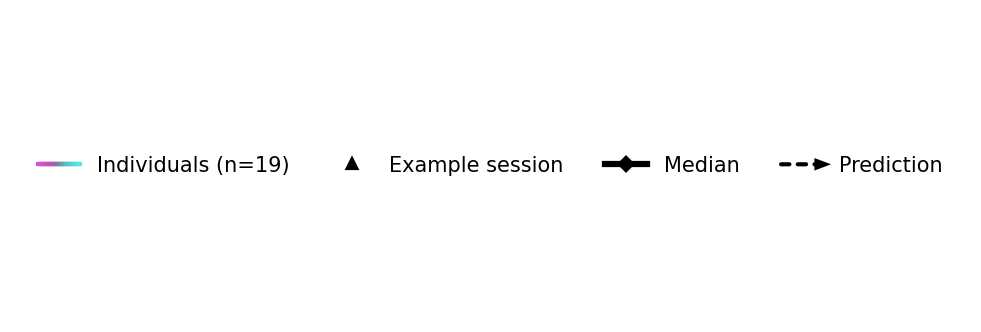

In [7]:

def dummy_legend(ax=None, animal_list=intact_rats):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    ex_session = ax.plot(2, 0, color='black', marker='^', zorder=10, markersize=2, linewidth=0, label='Example session')
    median = ax.plot([-100, -101], [-100, -101], color='k', marker='D', markersize=2, linestyle='-', lw=1.5, label=f'Median', zorder=5)

    arrow = mpatches.FancyArrowPatch((0, 0), (1, 0),
                                     arrowstyle='-|>', 
                                     lw=1, 
                                     color='k',
                                     linestyle='--')
    

    ax.axis('off')
    ax.set_xlim(10, 11)
    ax.set_ylim(10, 11)

    add_colored_intact(ax, handles=[ex_session, median, arrow], ncol=4,
                    labels=['Example session', 'Median', 'Prediction'], text=f'Individuals (n={len(animal_list)})', 
                    loc='center', bbox=(.5, .5), handler_map={mpatches.FancyArrowPatch: DashedArrowHandler()})


fig, axs = plt.subplots(1, 1, figsize=(cm2inch(3), cm2inch(3)))
dummy_legend(ax=axs)

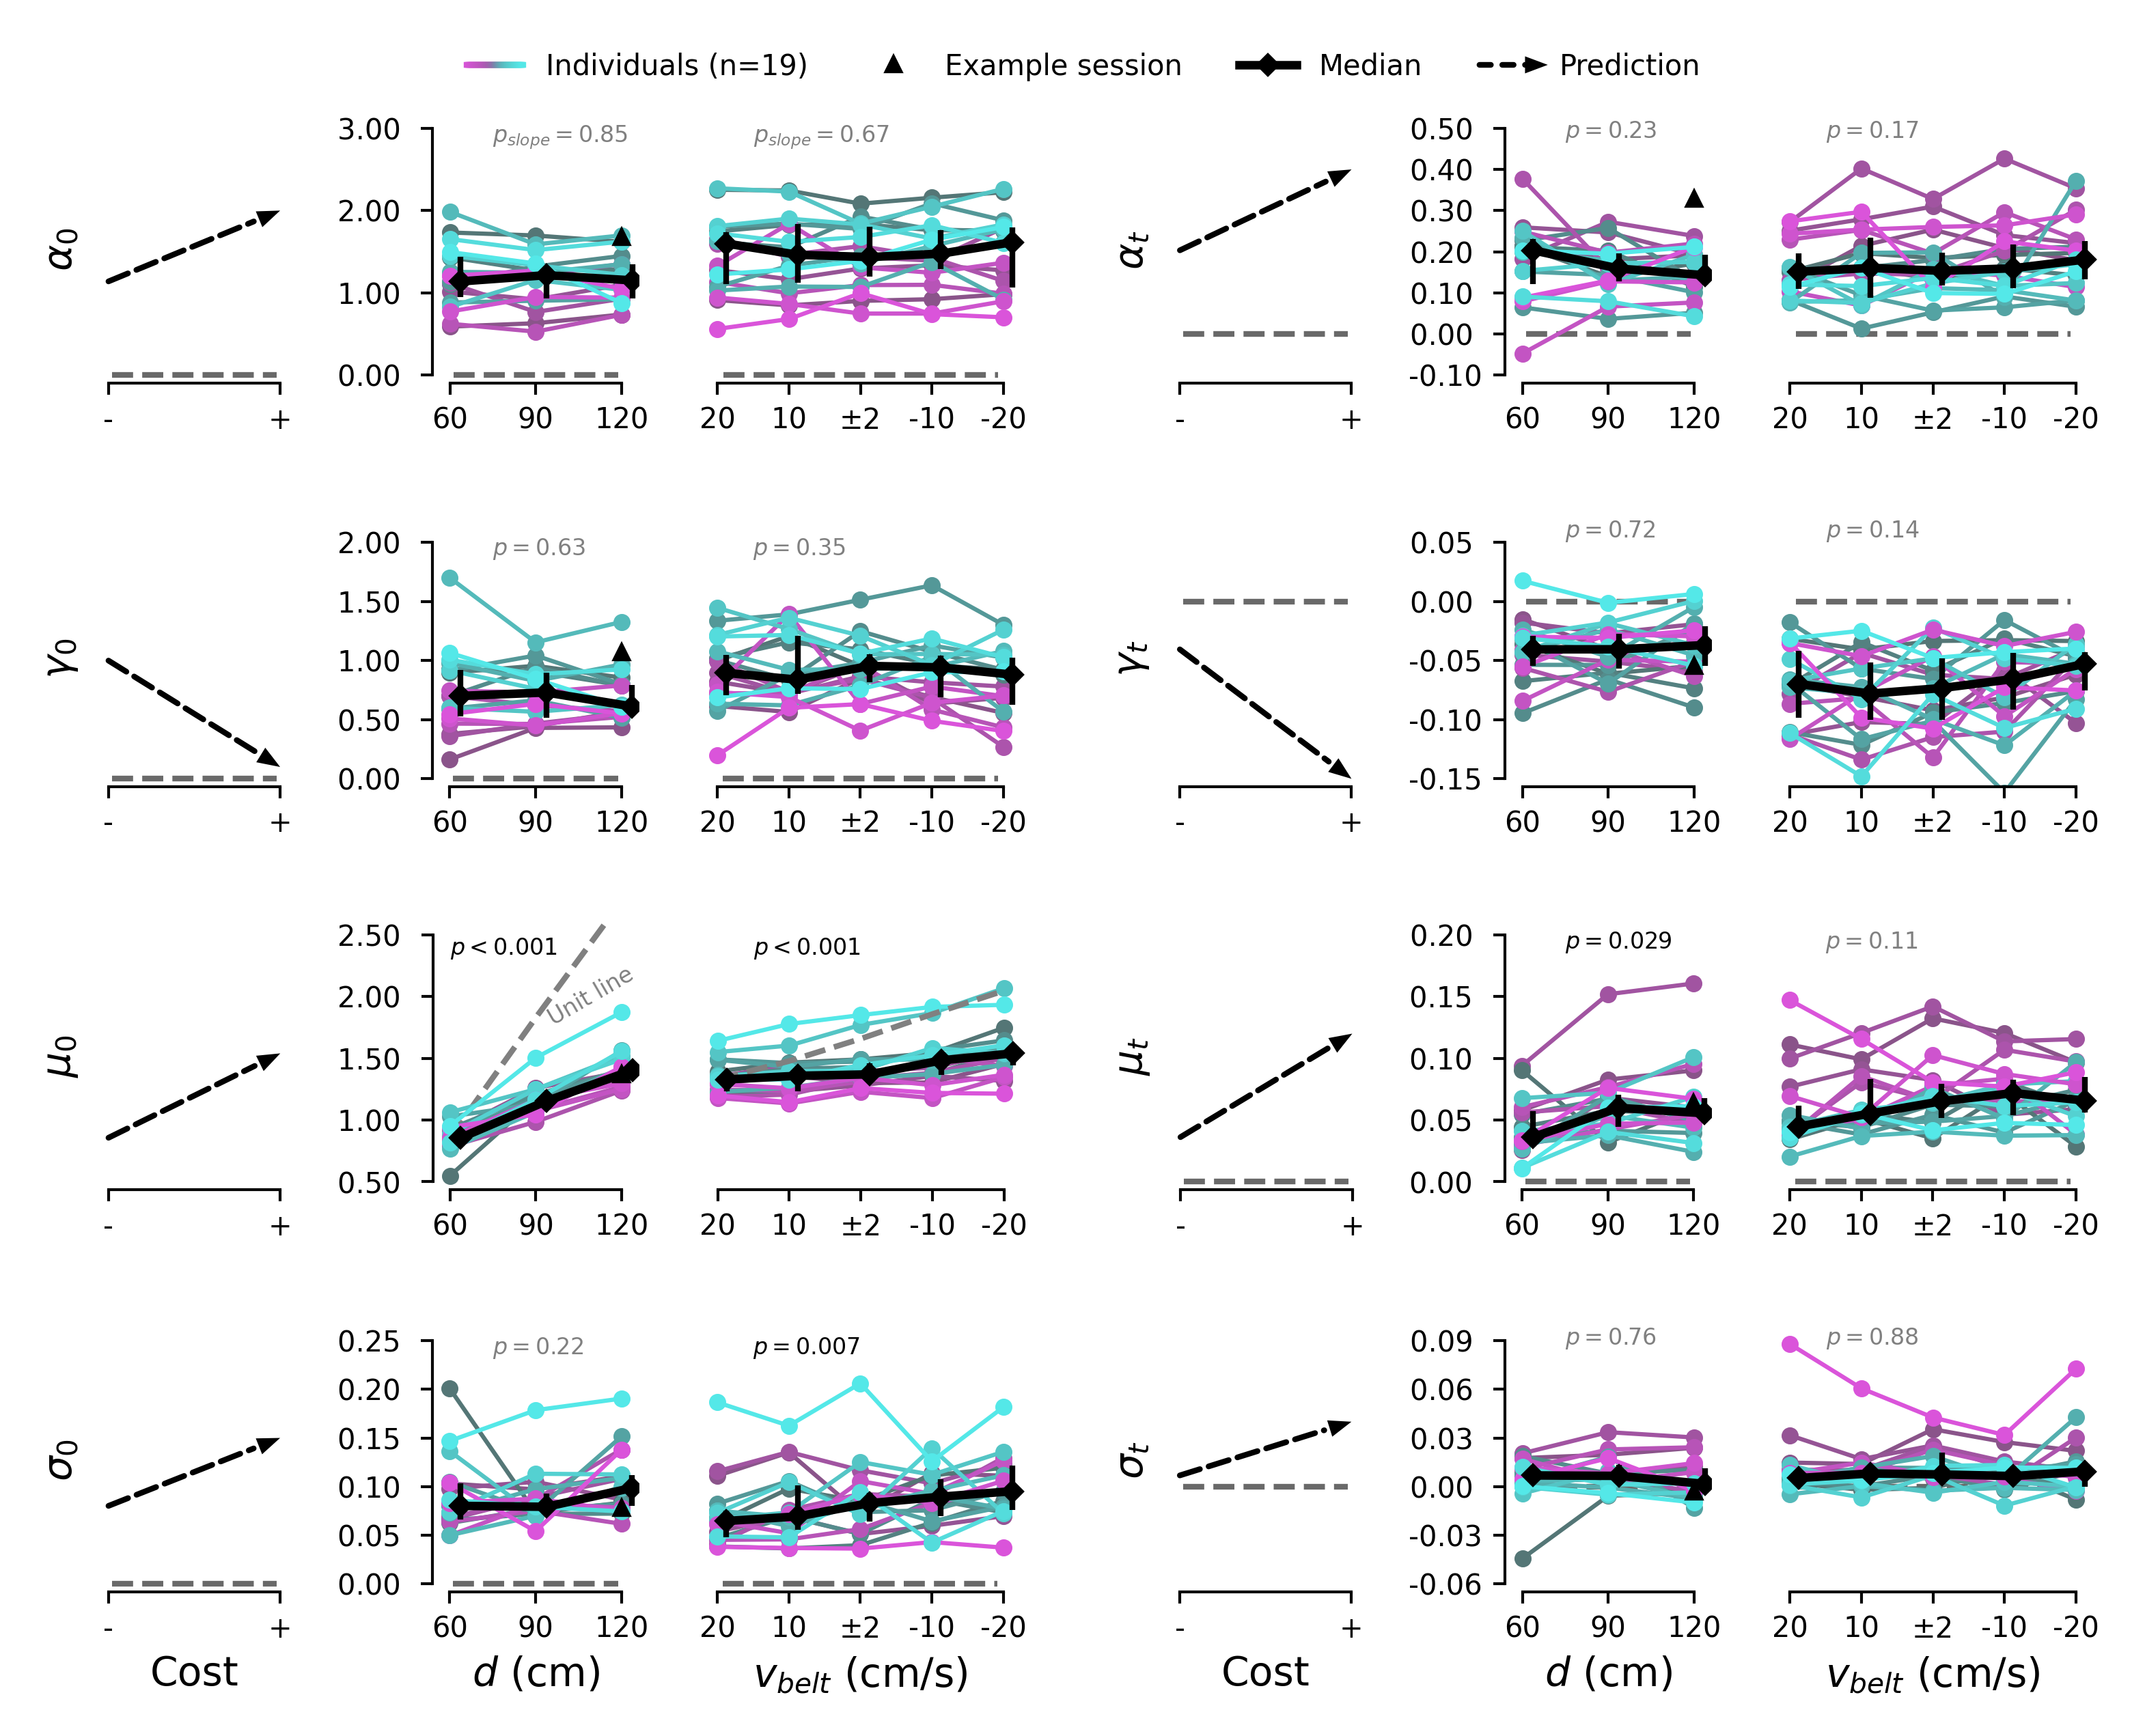

In [8]:

fig = plt.figure(figsize=(cm2inch(13), cm2inch(10)),
                #  constrained_layout=True,
                 facecolor='w', dpi=600)

pad = 0.0001
width_ratios = [3, 3, 5, pad, 3, 3, 5]
gs0 = fig.add_gridspec(4, 1, height_ratios=[1, 1, 1, 1])

row1 = gs0[0].subgridspec(1, 7, width_ratios=width_ratios)
ax_prediction_alpha_0 = plt.subplot(row1[0])
fit_alpha_0_distance = plt.subplot(row1[1])
fit_alpha_0_vbelt = plt.subplot(row1[2])

ax_prediction_alpha_t = plt.subplot(row1[4])
fit_alpha_t_distance = plt.subplot(row1[5])
fit_alpha_t_vbelt = plt.subplot(row1[6])

row2 = gs0[1].subgridspec(1, 7, width_ratios=width_ratios)
ax_prediction_gamma_0 = plt.subplot(row2[0])
fit_gamma_0_distance = plt.subplot(row2[1])
fit_gamma_0_vbelt = plt.subplot(row2[2])

ax_prediction_gamma_t = plt.subplot(row2[4])
fit_gamma_t_distance = plt.subplot(row2[5])
fit_gamma_t_vbelt = plt.subplot(row2[6])


row3 = gs0[2].subgridspec(1, 7, width_ratios=width_ratios)
ax_prediction_mu_0 = plt.subplot(row3[0])
fit_mu_0_distance = plt.subplot(row3[1])
fit_mu_0_vbelt = plt.subplot(row3[2])

ax_prediction_mu_t = plt.subplot(row3[4])
fit_mu_t_distance = plt.subplot(row3[5])
fit_mu_t_vbelt = plt.subplot(row3[6])

row4 = gs0[3].subgridspec(1, 7, width_ratios=width_ratios)
ax_prediction_sigma_0 = plt.subplot(row4[0])
fit_sigma_0_distance = plt.subplot(row4[1])
fit_sigma_0_vbelt = plt.subplot(row4[2])

ax_prediction_sigma_t = plt.subplot(row4[4])
fit_sigma_t_distance = plt.subplot(row4[5])
fit_sigma_t_vbelt = plt.subplot(row4[6])



plot_prediction('alpha_0', ax=ax_prediction_alpha_0, show_ylabel=True)
plot_prediction('alpha_t', ax=ax_prediction_alpha_t)
plot_prediction('gamma_0', ax=ax_prediction_gamma_0)
plot_prediction('gamma_t', ax=ax_prediction_gamma_t)
plot_prediction('mu_0', ax=ax_prediction_mu_0)
plot_prediction('mu_t', ax=ax_prediction_mu_t)
plot_prediction('sigma_0', ax=ax_prediction_sigma_0, show_xlabel=True)
plot_prediction('sigma_t', ax=ax_prediction_sigma_t, show_xlabel=True)


plot_model_parameter(PLOT_PARAMS['alpha_0'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_alpha_0_distance, animal_list=intact_rats, show_ylabel=False)
add_slope_pvalue(PLOT_PARAMS['alpha_0'], fit_alpha_0_distance, dist_or_tm='dist')
plot_model_parameter(PLOT_PARAMS['alpha_t'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_alpha_t_distance, animal_list=intact_rats)
add_slope_pvalue(PLOT_PARAMS['alpha_t'], fit_alpha_t_distance, dist_or_tm='dist')
plot_model_parameter(PLOT_PARAMS['gamma_0'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_gamma_0_distance, animal_list=intact_rats)
add_slope_pvalue(PLOT_PARAMS['gamma_0'], fit_gamma_0_distance, dist_or_tm='dist')
plot_model_parameter(PLOT_PARAMS['gamma_t'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_gamma_t_distance, animal_list=intact_rats)
add_slope_pvalue(PLOT_PARAMS['gamma_t'], fit_gamma_t_distance, dist_or_tm='dist')
plot_model_parameter(PLOT_PARAMS['mu_0'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_mu_0_distance, animal_list=intact_rats)
add_slope_pvalue(PLOT_PARAMS['mu_0'], fit_mu_0_distance, dist_or_tm='dist')
plot_model_parameter(PLOT_PARAMS['mu_t'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_mu_t_distance, animal_list=intact_rats)
add_slope_pvalue(PLOT_PARAMS['mu_t'], fit_mu_t_distance, dist_or_tm='dist')
plot_model_parameter(PLOT_PARAMS['sigma_0'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_sigma_0_distance, animal_list=intact_rats, show_xlabel=True)
add_slope_pvalue(PLOT_PARAMS['sigma_0'], fit_sigma_0_distance, dist_or_tm='dist')
plot_model_parameter(PLOT_PARAMS['sigma_t'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_sigma_t_distance, animal_list=intact_rats, show_xlabel=True)
add_slope_pvalue(PLOT_PARAMS['sigma_t'], fit_sigma_t_distance, dist_or_tm='dist')

plot_model_parameter(PLOT_PARAMS['alpha_0'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_alpha_0_vbelt, animal_list=intact_rats, hide_y=True)
add_slope_pvalue(PLOT_PARAMS['alpha_0'], fit_alpha_0_vbelt, dist_or_tm='tm')
plot_model_parameter(PLOT_PARAMS['alpha_t'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_alpha_t_vbelt, animal_list=intact_rats, hide_y=True)
add_slope_pvalue(PLOT_PARAMS['alpha_t'], fit_alpha_t_vbelt, dist_or_tm='tm')
plot_model_parameter(PLOT_PARAMS['gamma_0'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_gamma_0_vbelt, animal_list=intact_rats, hide_y=True)
add_slope_pvalue(PLOT_PARAMS['gamma_0'], fit_gamma_0_vbelt, dist_or_tm='tm')
plot_model_parameter(PLOT_PARAMS['gamma_t'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_gamma_t_vbelt, animal_list=intact_rats, hide_y=True)
add_slope_pvalue(PLOT_PARAMS['gamma_t'], fit_gamma_t_vbelt, dist_or_tm='tm')
plot_model_parameter(PLOT_PARAMS['mu_0'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_mu_0_vbelt, animal_list=intact_rats, hide_y=True)
add_slope_pvalue(PLOT_PARAMS['mu_0'], fit_mu_0_vbelt, dist_or_tm='tm')
plot_model_parameter(PLOT_PARAMS['mu_t'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_mu_t_vbelt, animal_list=intact_rats, hide_y=True)
add_slope_pvalue(PLOT_PARAMS['mu_t'], fit_mu_t_vbelt, dist_or_tm='tm')
plot_model_parameter(PLOT_PARAMS['sigma_0'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_sigma_0_vbelt, animal_list=intact_rats, show_xlabel=True, hide_y=True)
add_slope_pvalue(PLOT_PARAMS['sigma_0'], fit_sigma_0_vbelt, dist_or_tm='tm')
plot_model_parameter(PLOT_PARAMS['sigma_t'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_sigma_t_vbelt, animal_list=intact_rats, show_xlabel=True, hide_y=True)
add_slope_pvalue(PLOT_PARAMS['sigma_t'], fit_sigma_t_vbelt, dist_or_tm='tm')

avg60 = np.median([mu_0[animal]["60"] for animal in intact_rats])
x, y = [0, 1, 2], [avg60, (62/29)*avg60, (94/29)*avg60]
fit_mu_0_distance.plot(x, y, color='gray', linestyle='--', linewidth=1, alpha=1, zorder=0,)
fit_mu_0_distance.text(s='Unit line', x=1.1, y=2, ha="left", va="center", fontsize=4, color='gray', rotation= 30)
avg20 = np.median([mu_0[animal]["20"] for animal in intact_rats])
fit_mu_0_vbelt.plot([0, 1, 2, 3, 4], [(76.5/76.5)*avg20, (85.1/76.5)*avg20, (95.5/76.5)*avg20, 
                              (107/76.5)*avg20, (117.9/76.5)*avg20], 
                              color='gray', linestyle='--', linewidth=1, alpha=1, zorder=100)
legend = fig.add_axes([.5, 1.015, .01, .01])
dummy_legend(ax=legend)

# letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
# axs = [ax_prediction_alpha_0, ax_prediction_alpha_t, ax_prediction_gamma_0, ax_prediction_gamma_t, 
#        ax_prediction_mu_0, ax_prediction_mu_t, ax_prediction_sigma_0, ax_prediction_sigma_t]
# add_all_letters(axs,letters)
plt.savefig("./Figures_paper/Figure_3.pdf", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)
plt.savefig("./Figures_paper/Figure_3.svg", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="svg", dpi=600)

OTher option of figure

p_s=0.846, p_i=0.000, obs_slope=-0.010, obs_intercept=1.185
p_s=0.673, p_i=0.000, obs_slope=0.013, obs_intercept=1.444
p_s=0.233, p_i=0.000, obs_slope=-0.014, obs_intercept=0.177
p_s=0.173, p_i=0.000, obs_slope=0.008, obs_intercept=0.157
p_s=0.628, p_i=0.000, obs_slope=-0.021, obs_intercept=0.747
p_s=0.353, p_i=0.000, obs_slope=-0.019, obs_intercept=0.935
p_s=0.719, p_i=0.000, obs_slope=0.001, obs_intercept=-0.042
p_s=0.143, p_i=0.000, obs_slope=0.003, obs_intercept=-0.077
p_s=0.000, p_i=0.000, obs_slope=0.278, obs_intercept=0.870
p_s=0.000, p_i=0.000, obs_slope=0.054, obs_intercept=1.317
p_s=0.029, p_i=0.000, obs_slope=0.010, obs_intercept=0.047
p_s=0.107, p_i=0.000, obs_slope=0.003, obs_intercept=0.061
p_s=0.219, p_i=0.000, obs_slope=0.007, obs_intercept=0.087
p_s=0.007, p_i=0.000, obs_slope=0.007, obs_intercept=0.072
p_s=0.759, p_i=0.001, obs_slope=-0.001, obs_intercept=0.006
p_s=0.882, p_i=0.000, obs_slope=0.000, obs_intercept=0.011


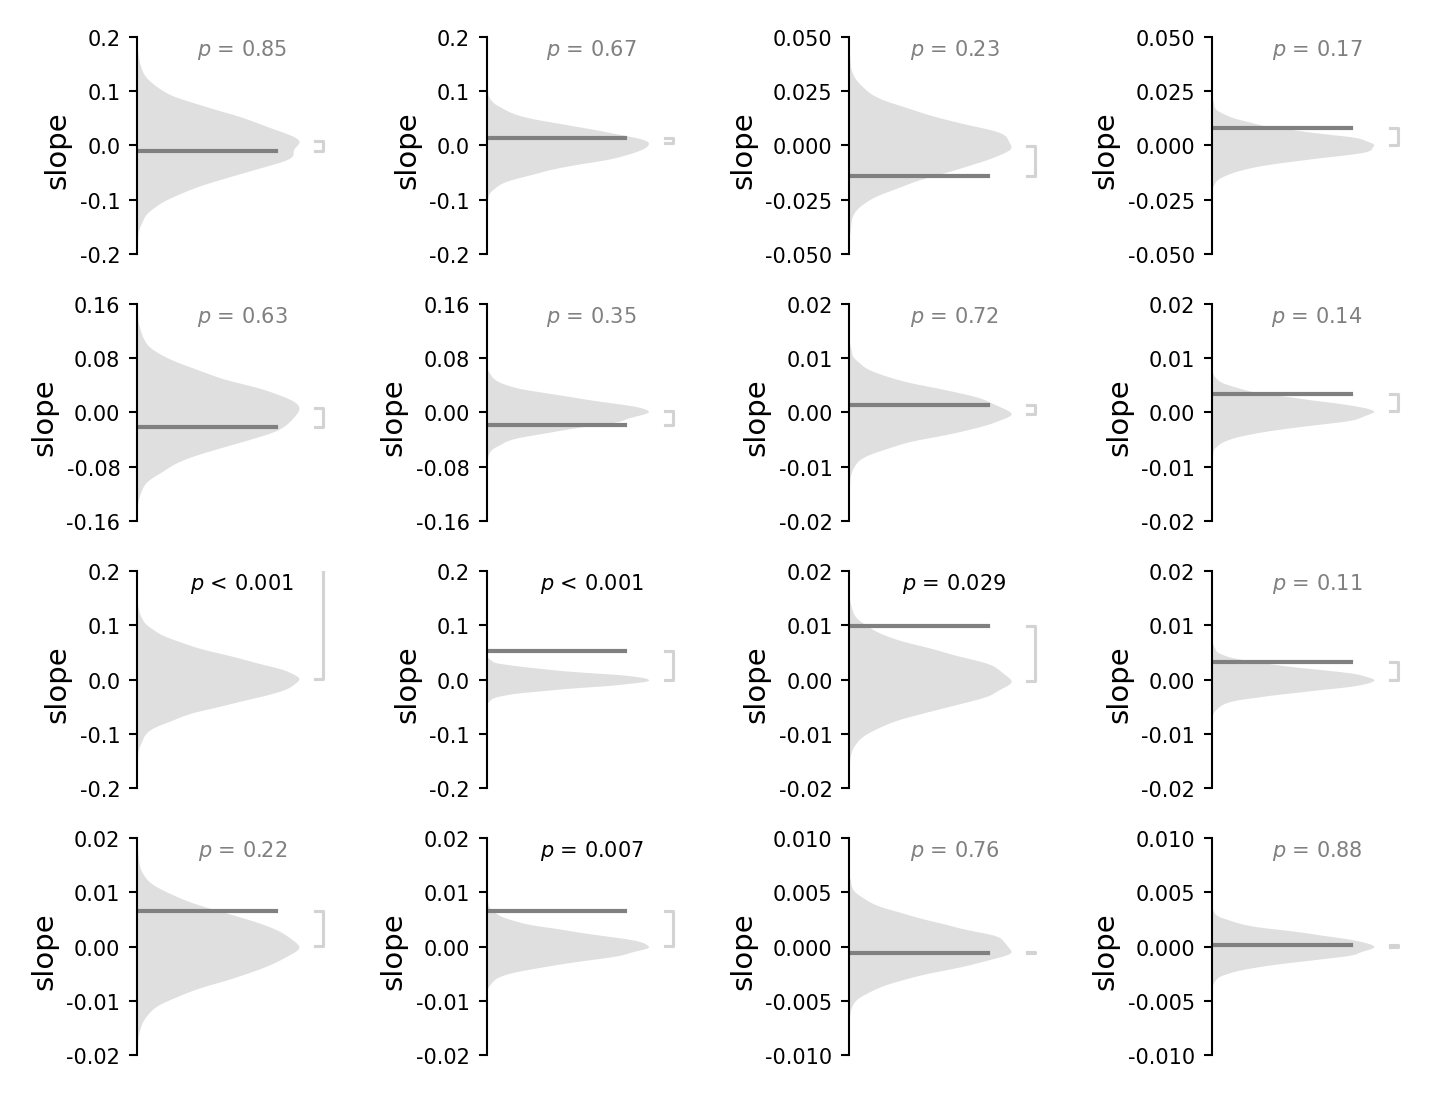

In [9]:
YTICKS_STATS = {
    'alpha_0': dict(slope = [-0.2, -0.1, 0, 0.1, 0.2], intercept = [0, 0.5, 1, 1.5, 2]),
    'alpha_t': dict(slope = [-0.05, -0.025, 0, 0.025, 0.05], intercept = [0, .05, .1, .15, .2, .25, .3]),
    'gamma_0': dict(slope=[-.16, -.08, 0, .08, .16], intercept=[0, .3, .6, .9, 1.2]),
    'gamma_t': dict(slope=[-0.02, -.01, 0, 0.01, 0.02], intercept=[-.09, -.06, -.03, 0, .03]),
    'mu_0': dict(slope=[-0.2, -0.1, 0, 0.1, 0.2], intercept=[0, 0.5, 1, 1.5]),
    'mu_t': dict(slope=[-0.02, -.01, 0, 0.01, 0.02], intercept=[-.05, 0, 0.05, .1]),
    'sigma_0': dict(slope=[-0.02, -.01, 0, 0.01, 0.02], intercept=[-.05, 0, 0.05, .1]),
    'sigma_t': dict(slope=[-.01, -.005, 0, .005, 0.01], intercept=[-.03, -.0015, 0, .0015, .03]),
}

def regression_permutation(var, dist_or_tm='dist', varname_slope='', varname_intercept='', raisy=0,
                           animal_list=[], color='k',
                           ax_slope=None, yticks_slope=None, 
                           ax_intercept=None, y_ticks_intercept=None, num_iterations=10000):
    ''' regression with permutation test for the slope and intercept
    var: parameter to test (e.g., alpha_0)
    dist_or_tm: 'dist' or 'tm'
    varname: name of the parameter
    lesioned_animals: True or False
    raisy: y position of the p-value
    ax_slope: axes object for the slope
    yticks_slope: yticks for the slope
    ax_intercept: axes object for the intercept
    y_ticks_intercept: yticks for the intercept
    '''

    rows = []
    _ = {"60": 0, "90": 1, "120": 2, "20": 0, "10": 1, "2": 2, "rev10": 3, "rev20": 4}

    for animal in animal_list:
        if dist_or_tm == 'dist':
            conds = ["60", "90", "120"]
        elif dist_or_tm == 'tm':
            conds = ["20", "10", "2", "rev10", "rev20"]
        else:
            raise ValueError("experiment must be 'dist' or 'tm'")
        for cond in conds:
            x = float(_[cond])
            y = var[animal][cond]
            rows.append({"animal": animal, "parameter": y, "cond": x})

    df = pd.DataFrame(rows)

    x = df.cond
    y = df.parameter

    # fit with np.polyfit
    f = lambda x, *p: np.polyval(p, x)
    p, cov = curve_fit(f, x, y, [1, 1])

    # shuffle to get p-value
    observed_slope = p[0]
    observed_intercept = p[1]
    slope_sign = np.sign(observed_slope)
    num_iterations = int(num_iterations)
    shuffled_slopes = []
    shuffled_intercepts = []

    np.random.seed(0)
    for _ in range(num_iterations):
        shuffled_y = np.random.permutation(y)
        shuffled_res, _ = curve_fit(f, x, shuffled_y, [1, 1])
        shuffled_slopes.append(shuffled_res[0])
        shuffled_intercepts.append(shuffled_res[1])

    # calculate the p-value
    p_value_slope = (np.abs(shuffled_slopes) >= np.abs(observed_slope)).mean()
    if observed_intercept >= 0:
        p_value_intercept = (np.asarray(shuffled_intercepts) <= 0).mean()
    else:
        p_value_intercept = (np.asarray(shuffled_intercepts) >= 0).mean()

    # compute r
    # y_mean = np.mean(y)
    # y_pred = f(x, *p)
    # ss_total = np.sum((y - y_mean) ** 2)
    # ss_res = np.sum((y - y_pred) ** 2)
    # r_squared = 1 - (ss_res / ss_total)
    # r = np.sqrt(r_squared)

    print(f'p_s={p_value_slope:.3f}, p_i={p_value_intercept:.3f}, obs_slope={observed_slope:.3f}, obs_intercept={observed_intercept:.3f}')
    plot_shuffling(shuffles=shuffled_slopes, pval=p_value_slope, observed=observed_slope, yticks=yticks_slope, ylabel=varname_slope, ax=ax_slope, color=color, raisy=raisy)
    if ax_intercept is not None:
        plot_shuffling(shuffles=shuffled_intercepts, pval=p_value_intercept, observed=observed_intercept, show_zero=True, yticks=y_ticks_intercept, ylabel=varname_intercept, ax=ax_intercept, color=color)

def Figure_stats(var, varname, dist_or_tm='dist', ax_slope=None, ax_intercept=None, intact=intact_rats):
    conds = ["60", "90", "120", "20", "10", "2", "rev10", "rev20"]
    mediandata = {animal: {cond: np.median(var[animal][cond]) for cond in conds} for animal in intact}
    regression_permutation(mediandata, dist_or_tm=dist_or_tm, animal_list=intact_rats, color='gray',
                           varname_slope='slope',
                           varname_intercept='intercept',
                        ax_slope=ax_slope, yticks_slope=YTICKS_STATS[varname]['slope'],
                        ax_intercept=ax_intercept, y_ticks_intercept=YTICKS_STATS[varname]['intercept'])
    
# Figure_stats(alpha_0, 'alpha_0', ax_slope=None, ax_intercept=None)
fig, axs = plt.subplots(4, 4, figsize=(cm2inch(12), cm2inch(9)))
param_names = [name for name in list(PLOT_PARAMS.keys()) for _ in (0, 1)]

for i, ax in enumerate(axs.ravel()):
    if i % 2 == 0:
        dist_or_tm = 'dist'
        ax_slope=axs.ravel()[i]
        ax_intercept=None
    else:
        dist_or_tm = 'tm'
        ax_slope=axs.ravel()[i]
        ax_intercept=None

    Figure_stats(var=PLOT_PARAMS[param_names[i]]['fit'], varname=param_names[i], dist_or_tm=dist_or_tm, 
                 ax_slope=ax_slope, 
                 ax_intercept=ax_intercept)


p_s=0.846, p_i=0.000, obs_slope=-0.010, obs_intercept=1.185
p_s=0.233, p_i=0.000, obs_slope=-0.014, obs_intercept=0.177
p_s=0.628, p_i=0.000, obs_slope=-0.021, obs_intercept=0.747
p_s=0.719, p_i=0.000, obs_slope=0.001, obs_intercept=-0.042
p_s=0.000, p_i=0.000, obs_slope=0.278, obs_intercept=0.870
p_s=0.029, p_i=0.000, obs_slope=0.010, obs_intercept=0.047
p_s=0.219, p_i=0.000, obs_slope=0.007, obs_intercept=0.087
p_s=0.759, p_i=0.001, obs_slope=-0.001, obs_intercept=0.006
p_s=0.673, p_i=0.000, obs_slope=0.013, obs_intercept=1.444
p_s=0.173, p_i=0.000, obs_slope=0.008, obs_intercept=0.157
p_s=0.353, p_i=0.000, obs_slope=-0.019, obs_intercept=0.935
p_s=0.143, p_i=0.000, obs_slope=0.003, obs_intercept=-0.077
p_s=0.000, p_i=0.000, obs_slope=0.054, obs_intercept=1.317
p_s=0.107, p_i=0.000, obs_slope=0.003, obs_intercept=0.061
p_s=0.007, p_i=0.000, obs_slope=0.007, obs_intercept=0.072
p_s=0.882, p_i=0.000, obs_slope=0.000, obs_intercept=0.011


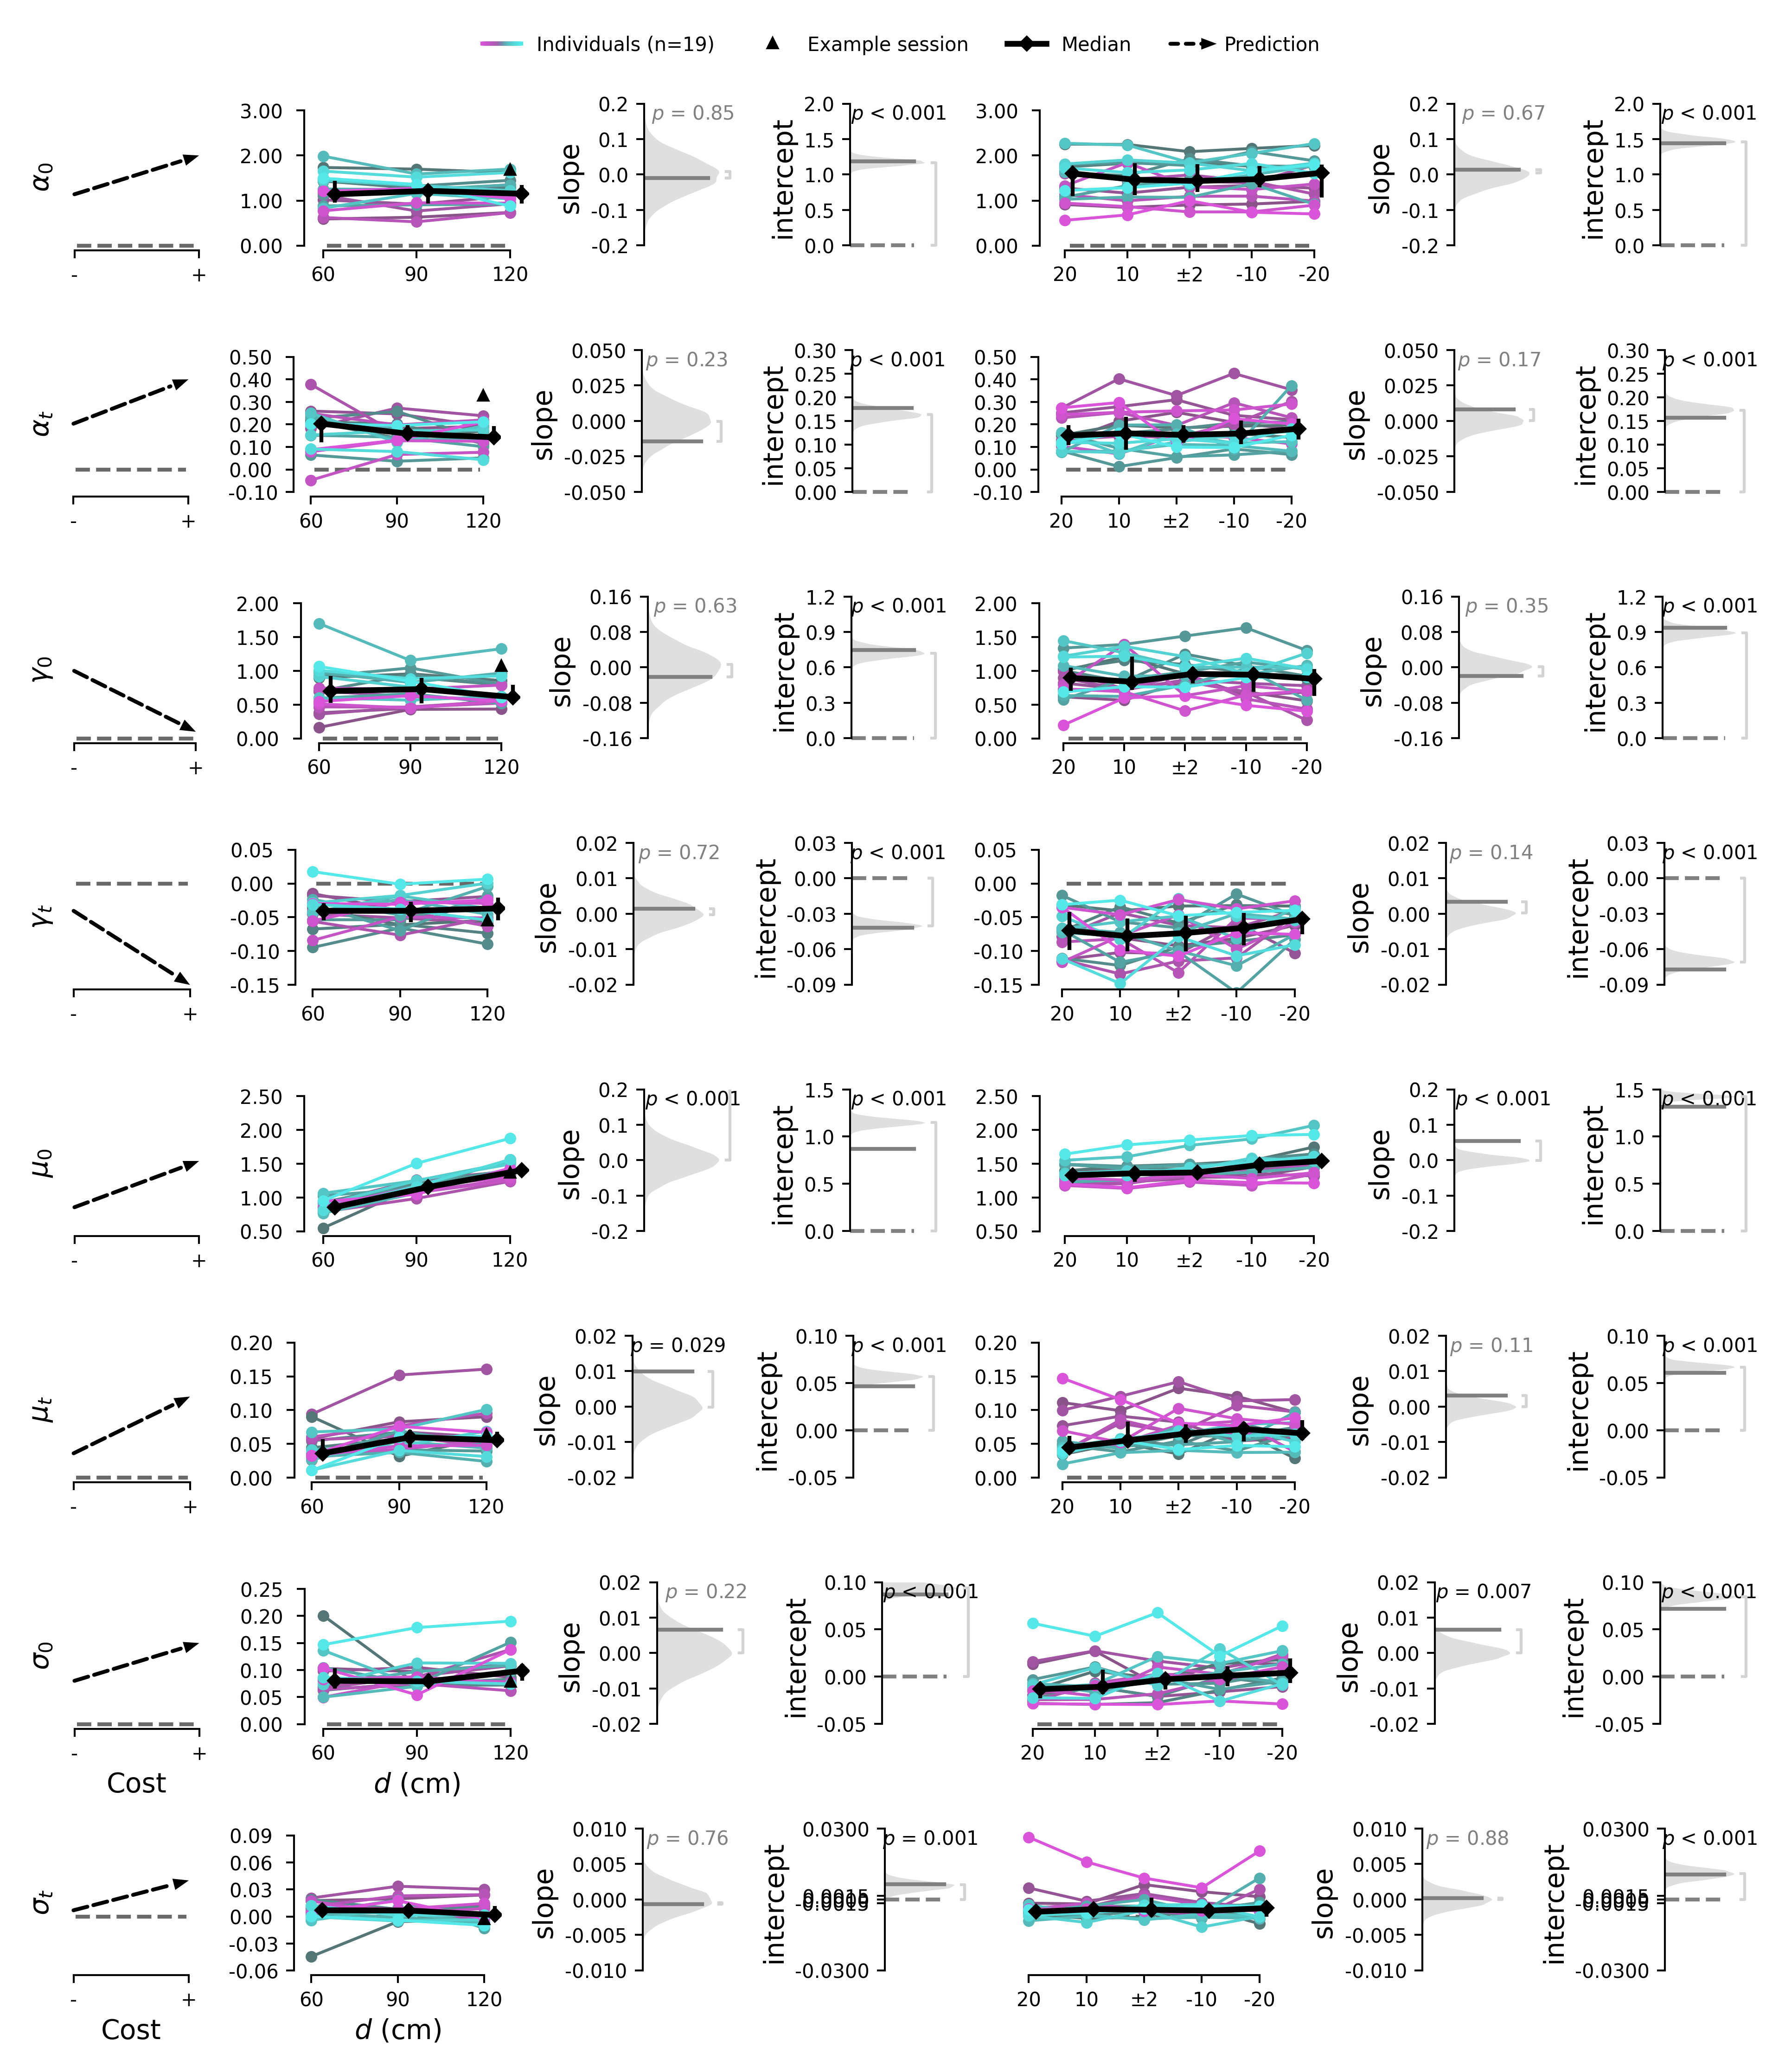

In [10]:

fig = plt.figure(figsize=(cm2inch(16), cm2inch(18)),
                #  constrained_layout=True,
                 facecolor='w', dpi=600)

pad = 0.01
width_ratios = [2, 3, 1.3, 1.3, 4, 1.3, 1.3]
gs0 = fig.add_gridspec(8, 1, height_ratios=[1, 1, 1, 1, 1, 1, 1, 1])

row1 = gs0[0].subgridspec(1, 7, width_ratios=width_ratios, wspace=0)
ax_prediction_alpha_0 = plt.subplot(row1[0])
fit_alpha_0_distance = plt.subplot(row1[1])
ax_slope_alpha_0_distance = plt.subplot(row1[2])
ax_intercept_alpha_0_distance = plt.subplot(row1[3])
fit_alpha_0_vbelt = plt.subplot(row1[4])
ax_slope_alpha_0_vbelt = plt.subplot(row1[5])
ax_intercept_alpha_0_vbelt = plt.subplot(row1[6])

row2 = gs0[1].subgridspec(1, 7, width_ratios=width_ratios, wspace=0)
ax_prediction_alpha_t = plt.subplot(row2[0])
fit_alpha_t_distance = plt.subplot(row2[1])
ax_slope_alpha_t_distance = plt.subplot(row2[2])
ax_intercept_alpha_t_distance = plt.subplot(row2[3])
fit_alpha_t_vbelt = plt.subplot(row2[4])
ax_slope_alpha_t_vbelt = plt.subplot(row2[5])
ax_intercept_alpha_t_vbelt = plt.subplot(row2[6])

row3 = gs0[2].subgridspec(1, 7, width_ratios=width_ratios, wspace=0)
ax_prediction_gamma_0 = plt.subplot(row3[0])
fit_gamma_0_distance = plt.subplot(row3[1])
ax_slope_gamma_0_distance = plt.subplot(row3[2])
ax_intercept_gamma_0_distance = plt.subplot(row3[3])
fit_gamma_0_vbelt = plt.subplot(row3[4])
ax_slope_gamma_0_vbelt = plt.subplot(row3[5])
ax_intercept_gamma_0_vbelt = plt.subplot(row3[6])

row4 = gs0[3].subgridspec(1, 7, width_ratios=width_ratios, wspace=0)
ax_prediction_gamma_t = plt.subplot(row4[0])
fit_gamma_t_distance = plt.subplot(row4[1])
ax_slope_gamma_t_distance = plt.subplot(row4[2])
ax_intercept_gamma_t_distance = plt.subplot(row4[3])
fit_gamma_t_vbelt = plt.subplot(row4[4])
ax_slope_gamma_t_vbelt = plt.subplot(row4[5])
ax_intercept_gamma_t_vbelt = plt.subplot(row4[6])

row5 = gs0[4].subgridspec(1, 7, width_ratios=width_ratios, wspace=0.005)
ax_prediction_mu_0 = plt.subplot(row5[0])
fit_mu_0_distance = plt.subplot(row5[1])
ax_slope_mu_0_distance = plt.subplot(row5[2])
ax_intercept_mu_0_distance = plt.subplot(row5[3])
fit_mu_0_vbelt = plt.subplot(row5[4])
ax_slope_mu_0_vbelt = plt.subplot(row5[5])
ax_intercept_mu_0_vbelt = plt.subplot(row5[6])

row6 = gs0[5].subgridspec(1, 7, width_ratios=width_ratios, wspace=0.005)
ax_prediction_mu_t = plt.subplot(row6[0])
fit_mu_t_distance = plt.subplot(row6[1])
ax_slope_mu_t_distance = plt.subplot(row6[2])
ax_intercept_mu_t_distance = plt.subplot(row6[3])
fit_mu_t_vbelt = plt.subplot(row6[4])
ax_slope_mu_t_vbelt = plt.subplot(row6[5])
ax_intercept_mu_t_vbelt = plt.subplot(row6[6])

row7 = gs0[6].subgridspec(1, 7, width_ratios=width_ratios, wspace=0.005)
ax_prediction_sigma_0 = plt.subplot(row7[0])
fit_sigma_0_distance = plt.subplot(row7[1])
ax_slope_sigma_0_distance = plt.subplot(row7[2])
ax_intercept_sigma_0_distance = plt.subplot(row7[3])
fit_sigma_0_vbelt = plt.subplot(row7[4])
ax_slope_sigma_0_vbelt = plt.subplot(row7[5])
ax_intercept_sigma_0_vbelt = plt.subplot(row7[6])

row8 = gs0[7].subgridspec(1, 7, width_ratios=width_ratios, wspace=0.005)
ax_prediction_sigma_t = plt.subplot(row8[0])
fit_sigma_t_distance = plt.subplot(row8[1])
ax_slope_sigma_t_distance = plt.subplot(row8[2])
ax_intercept_sigma_t_distance = plt.subplot(row8[3])
fit_sigma_t_vbelt = plt.subplot(row8[4])
ax_slope_sigma_t_vbelt = plt.subplot(row8[5])
ax_intercept_sigma_t_vbelt = plt.subplot(row8[6])



plot_prediction('alpha_0', ax=ax_prediction_alpha_0, show_ylabel=True)
plot_prediction('alpha_t', ax=ax_prediction_alpha_t)
plot_prediction('gamma_0', ax=ax_prediction_gamma_0)
plot_prediction('gamma_t', ax=ax_prediction_gamma_t)
plot_prediction('mu_0', ax=ax_prediction_mu_0)
plot_prediction('mu_t', ax=ax_prediction_mu_t)
plot_prediction('sigma_0', ax=ax_prediction_sigma_0, show_xlabel=True)
plot_prediction('sigma_t', ax=ax_prediction_sigma_t, show_xlabel=True)


plot_model_parameter(PLOT_PARAMS['alpha_0'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_alpha_0_distance, animal_list=intact_rats, show_ylabel=False)
plot_model_parameter(PLOT_PARAMS['alpha_t'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_alpha_t_distance, animal_list=intact_rats)
plot_model_parameter(PLOT_PARAMS['gamma_0'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_gamma_0_distance, animal_list=intact_rats)
plot_model_parameter(PLOT_PARAMS['gamma_t'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_gamma_t_distance, animal_list=intact_rats)
plot_model_parameter(PLOT_PARAMS['mu_0'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_mu_0_distance, animal_list=intact_rats)
plot_model_parameter(PLOT_PARAMS['mu_t'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_mu_t_distance, animal_list=intact_rats)
plot_model_parameter(PLOT_PARAMS['sigma_0'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_sigma_0_distance, animal_list=intact_rats, show_xlabel=True)
plot_model_parameter(PLOT_PARAMS['sigma_t'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_sigma_t_distance, animal_list=intact_rats, show_xlabel=True)

Figure_stats(var=alpha_0, varname='alpha_0', dist_or_tm='dist', ax_slope=ax_slope_alpha_0_distance, ax_intercept=ax_intercept_alpha_0_distance)
Figure_stats(var=alpha_t, varname='alpha_t', dist_or_tm='dist', ax_slope=ax_slope_alpha_t_distance, ax_intercept=ax_intercept_alpha_t_distance)
Figure_stats(var=gamma_0, varname='gamma_0', dist_or_tm='dist', ax_slope=ax_slope_gamma_0_distance, ax_intercept=ax_intercept_gamma_0_distance)
Figure_stats(var=gamma_t, varname='gamma_t', dist_or_tm='dist', ax_slope=ax_slope_gamma_t_distance, ax_intercept=ax_intercept_gamma_t_distance)
Figure_stats(var=mu_0, varname='mu_0', dist_or_tm='dist', ax_slope=ax_slope_mu_0_distance, ax_intercept=ax_intercept_mu_0_distance)
Figure_stats(var=mu_t, varname='mu_t', dist_or_tm='dist', ax_slope=ax_slope_mu_t_distance, ax_intercept=ax_intercept_mu_t_distance)
Figure_stats(var=sigma_0, varname='sigma_0', dist_or_tm='dist', ax_slope=ax_slope_sigma_0_distance, ax_intercept=ax_intercept_sigma_0_distance)
Figure_stats(var=sigma_t, varname='sigma_t', dist_or_tm='dist', ax_slope=ax_slope_sigma_t_distance, ax_intercept=ax_intercept_sigma_t_distance)
Figure_stats(var=alpha_0, varname='alpha_0', dist_or_tm='tm', ax_slope=ax_slope_alpha_0_vbelt, ax_intercept=ax_intercept_alpha_0_vbelt)
Figure_stats(var=alpha_t, varname='alpha_t', dist_or_tm='tm', ax_slope=ax_slope_alpha_t_vbelt, ax_intercept=ax_intercept_alpha_t_vbelt)
Figure_stats(var=gamma_0, varname='gamma_0', dist_or_tm='tm', ax_slope=ax_slope_gamma_0_vbelt, ax_intercept=ax_intercept_gamma_0_vbelt)
Figure_stats(var=gamma_t, varname='gamma_t', dist_or_tm='tm', ax_slope=ax_slope_gamma_t_vbelt, ax_intercept=ax_intercept_gamma_t_vbelt)
Figure_stats(var=mu_0, varname='mu_0', dist_or_tm='tm', ax_slope=ax_slope_mu_0_vbelt, ax_intercept=ax_intercept_mu_0_vbelt)
Figure_stats(var=mu_t, varname='mu_t', dist_or_tm='tm', ax_slope=ax_slope_mu_t_vbelt, ax_intercept=ax_intercept_mu_t_vbelt)
Figure_stats(var=sigma_0, varname='sigma_0', dist_or_tm='tm', ax_slope=ax_slope_sigma_0_vbelt, ax_intercept=ax_intercept_sigma_0_vbelt)
Figure_stats(var=sigma_t, varname='sigma_t', dist_or_tm='tm', ax_slope=ax_slope_sigma_t_vbelt, ax_intercept=ax_intercept_sigma_t_vbelt)

plot_model_parameter(PLOT_PARAMS['alpha_0'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_alpha_0_vbelt, animal_list=intact_rats, hide_y=False)
plot_model_parameter(PLOT_PARAMS['alpha_t'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_alpha_t_vbelt, animal_list=intact_rats, hide_y=False)
plot_model_parameter(PLOT_PARAMS['gamma_0'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_gamma_0_vbelt, animal_list=intact_rats, hide_y=False)
plot_model_parameter(PLOT_PARAMS['gamma_t'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_gamma_t_vbelt, animal_list=intact_rats, hide_y=False)
plot_model_parameter(PLOT_PARAMS['mu_0'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_mu_0_vbelt, animal_list=intact_rats, hide_y=False)
plot_model_parameter(PLOT_PARAMS['mu_t'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_mu_t_vbelt, animal_list=intact_rats, hide_y=False)
plot_model_parameter(PLOT_PARAMS['sigma_0'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_sigma_0_vbelt, animal_list=intact_rats, show_xlabel=False, hide_y=True)
plot_model_parameter(PLOT_PARAMS['sigma_t'], rat_markers, dist_or_tm='tm', show_ex=False, ax=fit_sigma_t_vbelt, animal_list=intact_rats, show_xlabel=False, hide_y=True)

legend = fig.add_axes([.5, 1.015, .01, .01])
dummy_legend(ax=legend)
plt.savefig("./Figures_paper/Figure_3.pdf", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)
plt.savefig("./Figures_paper/Figure_3.svg", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="svg", dpi=600)